
# NBA Shot Quality — End-to-End Classification + Expected Points (Fixed One‑Hot Strategy)

This notebook:
1. Loads and merges your 2014–2015 shot-by-shot CSV (Savant).
2. Keeps a copy of `player_name` **before** encoding.
3. One‑hot encodes categorical features **excluding** `name`.
4. Trains a baseline classifier (Gradient Boosting) to predict `shot_made_flag`.
5. Derives `shot_points` **from the one‑hot** `shot_type_3PT Field Goal` dummy (original strategy).
6. Computes per‑shot expected points, aggregates to player‑level **luck** (actual − expected).
7. Saves outputs (luck table CSV) for download.


In [7]:

import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

# File paths (already uploaded to /mnt/data)
# files = [
#     "nba_savant 2015-2016 a-h.csv",
#     "nba_savant 2015-2016 i-m.csv",
#     "nba_savant 2015-2016 n-z.csv",
# ]
files = ["enriched_data/nba_savant_2014_enriched_shots_v2.csv"]

files


['enriched_data/nba_savant_2014_enriched_shots_v2.csv']

In [8]:

dfs = []
for f in files:
    assert os.path.exists(f), f"Missing file: {f}"
    dfs.append(pd.read_csv(f))

df = pd.concat(dfs, ignore_index=True)
print("Merged shape:", df.shape)
df.head()


Merged shape: (205550, 29)


,name,team_name,game_date,season,espn_player_id,team_id,espn_game_id,period,minutes_remaining,seconds_remaining,...,defender_name,defender_distance,shot_clock,team,SHOT_CLOCK_APPROX,SHOT_CLOCK_SOURCE,contest_score,contest_label,contest_reasons,shotValue
0,Kevin Love,Cleveland Cavaliers,2014-10-31,2014,3449.0,1610612739,400578314.0,3,3,20,...,"Dunleavy, Mike",1.3,11.8,CLE,11.8,from_savant_shot_clock,1,borderline,location: at-rim/very close,2
1,Timofey Mozgov,Cleveland Cavaliers,2015-04-10,2014,4298.0,1610612739,400579470.0,1,4,50,...,"Zeller, Tyler",3.7,11.0,CLE,11.0,from_savant_shot_clock,1,borderline,location: at-rim/very close,2
2,Tristan Thompson,Cleveland Cavaliers,2014-11-29,2014,6474.0,1610612739,400578530.0,3,11,11,...,"Sloan, Donald",0.5,14.9,CLE,14.9,from_savant_shot_clock,1,borderline,location: at-rim/very close,2
3,Tristan Thompson,Cleveland Cavaliers,2015-01-30,2014,6474.0,1610612739,400578992.0,2,0,2,...,"Cousins, DeMarcus",2.6,0.0,CLE,0.0,from_savant_shot_clock,2,likely_contested,"location: at-rim/very close, clock: late-clock...",2
4,LeBron James,Cleveland Cavaliers,2014-12-21,2014,1966.0,1610612739,400578693.0,4,10,11,...,"Pondexter, Quincy",5.4,19.0,CLE,19.0,from_savant_shot_clock,1,borderline,location: at-rim/very close,2


In [9]:

# Keep copy for grouping later (do not encode this column)
df["player_name"] = df["name"]

# Target
target_col = "shot_made_flag"
assert target_col in df.columns, f"Missing target column: {target_col}"

# Optional: drop clear identifiers not used as features
drop_cols_if_present = ["game_date", "season", "espn_player_id", "team_id", "espn_game_id"]
for c in drop_cols_if_present:
    if c in df.columns:
        pass  # keep them around for now; safe to drop later if desired

# Show columns
df.columns.tolist()


['name',
 'team_name',
 'game_date',
 'season',
 'espn_player_id',
 'team_id',
 'espn_game_id',
 'period',
 'minutes_remaining',
 'seconds_remaining',
 'shot_made_flag',
 'action_type',
 'shot_type',
 'shot_distance',
 'opponent',
 'x',
 'y',
 'dribbles',
 'touch_time',
 'defender_name',
 'defender_distance',
 'shot_clock',
 'team',
 'SHOT_CLOCK_APPROX',
 'SHOT_CLOCK_SOURCE',
 'contest_score',
 'contest_label',
 'contest_reasons',
 'shotValue',
 'player_name']

In [10]:

# Define columns based on your sample schema
categorical_cols = ["team_name", "opponent", "action_type", "shot_type", "defender_name"]
numeric_cols = [
    "period", "minutes_remaining", "seconds_remaining",
    "shot_distance", "x", "y", "dribbles", "touch_time",
    "defender_distance", "shot_clock"
]

# Safety: ensure these columns exist
missing_cats = [c for c in categorical_cols if c not in df.columns]
missing_nums = [c for c in numeric_cols if c not in df.columns]
if missing_cats or missing_nums:
    print("Note: Some expected columns are missing. "
          f"Missing categoricals: {missing_cats}, missing numerics: {missing_nums}")

# Fill categorical NAs to a string
for c in categorical_cols:
    if c in df.columns:
        df[c] = df[c].fillna("Unknown")

# Coerce numerics (strings like '00' → 0; NAs → 0)
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0.0)

# Confirm dtypes
df[numeric_cols].dtypes


period                 int64
minutes_remaining      int64
seconds_remaining      int64
shot_distance          int64
x                      int64
y                      int64
dribbles               int64
touch_time           float64
defender_distance    float64
shot_clock           float64
dtype: object

In [11]:

df_enc = pd.get_dummies(df, columns=[c for c in categorical_cols if c in df.columns], drop_first=True)

# Build X (numeric + encoded categorical) and y
encoded_cols = [c for c in df_enc.columns if any((f"{base}_" in c) for base in categorical_cols)]
X_cols = [c for c in numeric_cols if c in df_enc.columns] + encoded_cols

# Ensure only numeric in X
X = df_enc[X_cols].apply(pd.to_numeric, errors="raise")
y = df_enc[target_col].astype(int)

X.shape, y.shape


((205550, 613), (205550,))

In [12]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = GradientBoostingClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(f"GradientBoost: acc={accuracy_score(y_test, y_pred):.3f}, auc={roc_auc_score(y_test, y_proba):.3f}")


GradientBoost: acc=0.663, auc=0.704


In [13]:

# Use one‑hot 3PT dummy to derive shot_points (original strategy)
three_dummy_candidates = [c for c in df_enc.columns if c.startswith("shot_type_") and "3PT" in c]

if len(three_dummy_candidates) == 0:
    # Fallback to raw text (rare; e.g., if drop_first removed the only 3PT category name)
    print("Warning: Could not find a 'shot_type_...3PT...' dummy. Falling back to raw text parsing.")
    df_enc["shot_points"] = df["shot_type"].str.contains("3PT", na=False).astype(int)
    df_enc["shot_points"] = df_enc["shot_points"].replace({1: 3, 0: 2})
else:
    three_col = three_dummy_candidates[0]
    df_enc["shot_points"] = df_enc[three_col] * 3 + (1 - df_enc[three_col]) * 2

# Predicted make probability for all rows
df_enc["make_prob"] = model.predict_proba(X)[:, 1]

# Expected & actual points
df_enc["expected_points"] = df_enc["make_prob"] * df_enc["shot_points"]
df_enc["actual_points"] = df_enc[target_col] * df_enc["shot_points"]

df_enc[["player_name", "shot_points", "make_prob", "expected_points", "actual_points"]].head()


,player_name,shot_points,make_prob,expected_points,actual_points
0,Kevin Love,2,0.799533,1.599065,2
1,Timofey Mozgov,2,0.800076,1.600152,2
2,Tristan Thompson,2,0.850189,1.700378,2
3,Tristan Thompson,2,0.809163,1.618326,0
4,LeBron James,2,0.917422,1.834844,2


In [14]:

player_summary = df_enc.groupby("player_name").agg(
    exp_points=("expected_points", "sum"),
    actual_points=("actual_points", "sum"),
    shots=(target_col, "count")
).sort_index()

player_summary["luck"] = player_summary["actual_points"] - player_summary["exp_points"]

print("Top 10 luckiest (actual - expected):")
display(player_summary.sort_values("luck", ascending=False).head(10))

print("\nTop 10 unluckiest:")
display(player_summary.sort_values("luck", ascending=True).head(10))

# Save CSV for download
out_csv = "player_luck_summary.csv"
player_summary.to_csv(out_csv)
out_csv


Top 10 luckiest (actual - expected):


,exp_points,actual_points,shots,luck
player_name,,,,
Chris Paul,1033.150162,1275,1171,241.849838
Kyle Korver,615.687036,805,600,189.312964
JJ Redick,928.950035,1094,938,165.049965
Al Jefferson,810.830932,974,1010,163.169068
Rudy Gay,964.263010,1095,1116,130.736990
Anthony Davis,1154.510325,1285,1199,130.489675
Kyrie Irving,1187.438651,1310,1234,122.561349
Tony Parker,732.977991,846,832,113.022009
Nikola Vucevic,1153.545341,1264,1206,110.454659



Top 10 unluckiest:


,exp_points,actual_points,shots,luck
player_name,,,,
Dion Waiters,971.521461,823,946,-148.521461
Russell Westbrook,1479.816884,1340,1471,-139.816884
Corey Brewer,878.246309,746,805,-132.246309
Andre Drummond,1107.881697,988,962,-119.881697
Draymond Green,907.726170,789,765,-118.726170
Victor Oladipo,1133.468573,1030,1086,-103.468573
Trevor Ariza,1019.922466,926,910,-93.922466
Josh Smith,989.716459,900,986,-89.716459
DeMar DeRozan,921.884159,843,990,-78.884159


'player_luck_summary.csv'


### Optional: Team/Game-Level Aggregation

You can repeat a similar aggregation at the game or team level by grouping on
`['team_name', 'espn_game_id']` (or date) to build features for win prediction.


### Z statistic test
P values for all the players to see how statistically significant their results were.




In [15]:
from math import erf, sqrt

def z_test_points(y, p, w):
    """
    Points-weighted z-test for luck significance.
    y : 0/1 array of shot outcomes
    p : predicted make probabilities
    w : shot values (2 or 3)
    Returns: z, pval, actual_points, expected_points
    """
    y = np.asarray(y, float)
    p = np.asarray(p, float)
    w = np.asarray(w, float)

    S = np.sum(w * y)                # actual points
    mu = np.sum(w * p)               # expected points
    var = np.sum((w**2) * p * (1 - p))  # variance
    if var <= 0:
        return np.nan, np.nan, S, mu

    z = (S - mu) / np.sqrt(var)
    Phi = lambda x: 0.5 * (1 + erf(x / sqrt(2)))
    pval = 2 * (1 - Phi(abs(z)))
    return z, pval, S, mu

# Apply per player
records = []
for player, grp in df_enc.groupby("player_name"):
    y_i = grp[target_col].values
    p_i = grp["make_prob"].values
    w_i = grp["shot_points"].values
    z, pval, actual, expected = z_test_points(y_i, p_i, w_i)
    records.append({
        "player_name": player,
        "shots": len(grp),
        "actual_points": actual,
        "expected_points": expected,
        "z_score": z,
        "p_value": pval,
        "luck": actual - expected
    })

player_pvals = pd.DataFrame(records).sort_values("p_value")
player_pvals.head(100)


,player_name,shots,actual_points,expected_points,z_score,p_value,luck
80,Chris Paul,1171,1275.0,1033.150162,6.438868,1.203677e-10,241.849838
287,Kyle Korver,600,805.0,615.687036,5.838900,5.254646e-09,189.312964
5,Al Jefferson,1010,974.0,810.830932,5.452157,4.976236e-08,163.169068
119,Dion Waiters,946,823.0,971.521461,-4.458359,8.258959e-06,-148.521461
186,JJ Redick,938,1094.0,928.950035,4.435855,9.170776e-06,165.049965
...,...,...,...,...,...,...,...
369,PJ Hairston,269,223.0,264.674308,-2.024738,4.289427e-02,-41.674308
79,Chris Kaman,549,566.0,521.197181,2.008744,4.456428e-02,44.802819
413,Ryan Kelly,309,253.0,294.051362,-2.000985,4.539395e-02,-41.051362
144,Eric Moreland,1,2.0,0.405535,1.982867,4.738225e-02,1.594465


In [16]:
# Sort by "luck" (descending: luckiest players first)
luck_sorted = player_pvals.sort_values("luck", ascending=False)
print("Top 10 luckiest players:")
display(luck_sorted.head(10))

print("\nTop 10 unluckiest players:")
display(luck_sorted.tail(10))

# Sort by p-value (ascending: most significant first)
pval_sorted = player_pvals.sort_values("p_value", ascending=True)
print("\nTop 10 most statistically significant deviations:")
display(pval_sorted.head(10))

print("\nTop 10 least statistically significant deviations:")
display(pval_sorted.tail(10))



Top 10 luckiest players:


,player_name,shots,actual_points,expected_points,z_score,p_value,luck
80,Chris Paul,1171,1275.0,1033.150162,6.438868,1.203677e-10,241.849838
287,Kyle Korver,600,805.0,615.687036,5.838900,5.254646e-09,189.312964
186,JJ Redick,938,1094.0,928.950035,4.435855,9.170776e-06,165.049965
5,Al Jefferson,1010,974.0,810.830932,5.452157,4.976236e-08,163.169068
407,Rudy Gay,1116,1095.0,964.263010,3.819913,1.334985e-04,130.736990
29,Anthony Davis,1199,1285.0,1154.510325,4.101160,4.110839e-05,130.489675
291,Kyrie Irving,1234,1310.0,1187.438651,3.191878,1.413512e-03,122.561349
455,Tony Parker,832,846.0,732.977991,3.918763,8.900469e-05,113.022009
361,Nikola Vucevic,1206,1264.0,1153.545341,3.327129,8.774579e-04,110.454659
30,Anthony Morrow,615,711.0,604.383548,3.496309,4.717412e-04,106.616452



Top 10 unluckiest players:


,player_name,shots,actual_points,expected_points,z_score,p_value,luck
352,Nerlens Noel,653,604.0,680.024342,-3.316425,0.000912,-76.024342
108,DeMar DeRozan,990,843.0,921.884159,-2.521130,0.011698,-78.884159
257,Josh Smith,986,900.0,989.716459,-2.664022,0.007721,-89.716459
460,Trevor Ariza,910,926.0,1019.922466,-2.469748,0.013521,-93.922466
476,Victor Oladipo,1086,1030.0,1133.468573,-2.960586,0.003071,-103.468573
125,Draymond Green,765,789.0,907.726170,-3.647253,0.000265,-118.726170
19,Andre Drummond,962,988.0,1107.881697,-4.282050,0.000019,-119.881697
85,Corey Brewer,805,746.0,878.246309,-4.288344,0.000018,-132.246309
410,Russell Westbrook,1471,1340.0,1479.816884,-3.509913,0.000448,-139.816884
119,Dion Waiters,946,823.0,971.521461,-4.458359,0.000008,-148.521461



Top 10 most statistically significant deviations:


,player_name,shots,actual_points,expected_points,z_score,p_value,luck
80,Chris Paul,1171,1275.0,1033.150162,6.438868,1.203677e-10,241.849838
287,Kyle Korver,600,805.0,615.687036,5.838900,5.254646e-09,189.312964
5,Al Jefferson,1010,974.0,810.830932,5.452157,4.976236e-08,163.169068
119,Dion Waiters,946,823.0,971.521461,-4.458359,8.258959e-06,-148.521461
186,JJ Redick,938,1094.0,928.950035,4.435855,9.170776e-06,165.049965
85,Corey Brewer,805,746.0,878.246309,-4.288344,1.800104e-05,-132.246309
19,Andre Drummond,962,988.0,1107.881697,-4.282050,1.851792e-05,-119.881697
29,Anthony Davis,1199,1285.0,1154.510325,4.101160,4.110839e-05,130.489675
154,Gary Harris,217,153.0,223.446138,-4.005144,6.197973e-05,-70.446138
455,Tony Parker,832,846.0,732.977991,3.918763,8.900469e-05,113.022009



Top 10 least statistically significant deviations:


,player_name,shots,actual_points,expected_points,z_score,p_value,luck
396,Richard Jefferson,324,354.0,354.673123,-0.031472,0.974893,-0.673123
421,Shabazz Napier,228,217.0,216.468257,0.029343,0.976591,0.531743
93,Danilo Gallinari,568,563.0,563.772149,-0.026639,0.978747,-0.772149
231,Jodie Meeks,534,518.0,518.667032,-0.024969,0.980080,-0.667032
147,Evan Fournier,575,591.0,590.364332,0.023167,0.981517,0.635668
46,Boris Diaw,632,636.0,636.567319,-0.020437,0.983695,-0.567319
40,Ben McLemore,831,866.0,865.306425,0.020430,0.983700,0.693575
94,Danny Granger,162,160.0,160.304678,-0.019578,0.984380,-0.304678
459,Travis Wear,209,179.0,178.942087,0.003876,0.996908,0.057913
214,Jason Thompson,428,402.0,402.021545,-0.001116,0.999110,-0.021545


### Data visualization


In [17]:
# Make sure shot_made_flag is numeric
df['shot_made_flag'] = df['shot_made_flag'].astype(int)

# Add shot points (2 or 3) based on shot_type
df['shot_points'] = np.where(df['shot_type'].str.contains('3PT', na=False), 3, 2)

# Actual points scored for each shot
df['actual_points'] = df['shot_made_flag'] * df['shot_points']


Matplotlib is building the font cache; this may take a moment.


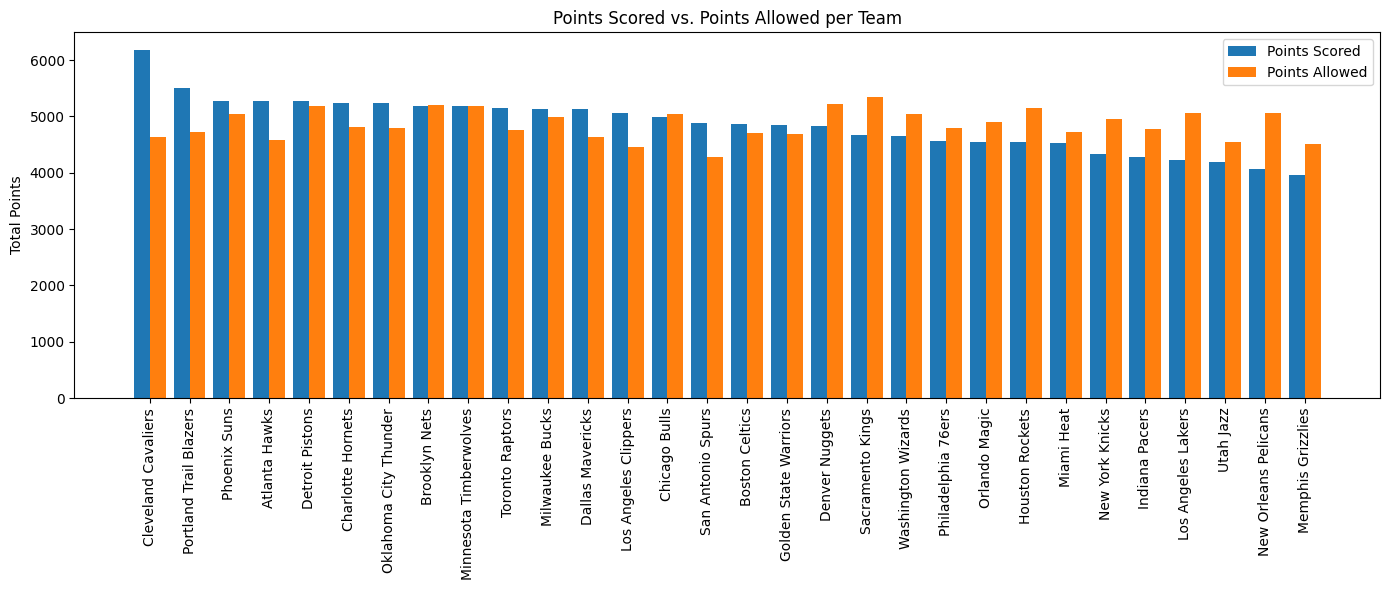

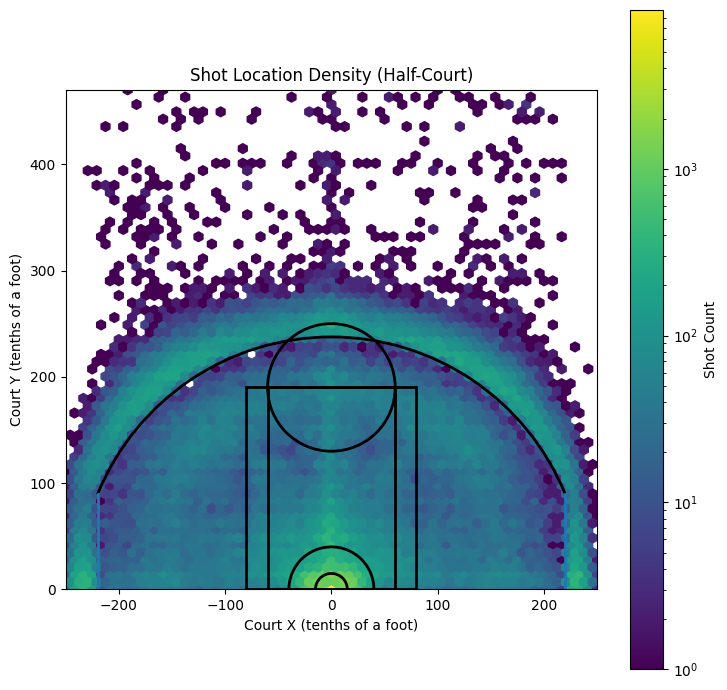

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, Arc
from matplotlib.lines import Line2D

# -------------------------------------------------------------------
# Load data
# -------------------------------------------------------------------
files = [
    "nba_savant 2015-2016 a-h.csv",
    "nba_savant 2015-2016 i-m.csv",
    "nba_savant 2015-2016 n-z.csv",
]
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

# Compute points per shot
df['shot_made_flag'] = df['shot_made_flag'].astype(int)
df['shot_points'] = np.where(df['shot_type'].str.contains('3PT', na=False), 3, 2)
df['actual_points'] = df['shot_made_flag'] * df['shot_points']

# -------------------------------------------------------------------
# 1) Points scored vs allowed (grouped bar chart)
# -------------------------------------------------------------------
points_scored = df.groupby('team_name', as_index=False)['actual_points'].sum()
points_scored = points_scored.rename(columns={'actual_points':'points_scored'})

points_allowed = df.groupby('opponent', as_index=False)['actual_points'].sum()
points_allowed = points_allowed.rename(columns={'opponent':'team_name','actual_points':'points_allowed'})

team_points = pd.merge(points_scored, points_allowed, on='team_name')
team_points = team_points.sort_values('points_scored', ascending=False)

x = np.arange(len(team_points))
w = 0.4

plt.figure(figsize=(14,6))
plt.bar(x - w/2, team_points['points_scored'], width=w, label='Points Scored')
plt.bar(x + w/2, team_points['points_allowed'], width=w, label='Points Allowed')
plt.xticks(x, team_points['team_name'], rotation=90)
plt.title('Points Scored vs. Points Allowed per Team')
plt.ylabel('Total Points')
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# 2) Shot location density with half-court overlay (tenths of feet)
# -------------------------------------------------------------------
def draw_nba_half_court_tenths(ax, lw=2):
    """Draw NBA half-court in tenths-of-feet coordinates."""
    u = 10.0  # conversion factor feet -> tenths of feet

    # Dimensions in feet
    rim_r_ft, backboard_w_ft, backboard_y_ft = 1.5, 6.0, -0.625
    lane_w_outer_ft, lane_w_inner_ft, lane_h_ft = 16.0, 12.0, 19.0
    ft_circle_r_ft, restricted_r_ft = 6.0, 4.0
    corner_x_ft, three_r_ft = 22.0, 23.75

    # Convert to tenths-of-feet
    rim_r        = rim_r_ft * u
    backboard_w  = backboard_w_ft * u
    backboard_y  = backboard_y_ft * u
    lane_w_outer = lane_w_outer_ft * u
    lane_w_inner = lane_w_inner_ft * u
    lane_h       = lane_h_ft * u
    ft_circle_r  = ft_circle_r_ft * u
    restricted_r = restricted_r_ft * u
    corner_x     = corner_x_ft * u
    three_r      = three_r_ft * u

    corner_y  = float(np.sqrt(max(three_r**2 - corner_x**2, 0.0)))
    theta_deg = float(np.degrees(np.arccos(corner_x / three_r)))
    theta1, theta2 = theta_deg, 180.0 - theta_deg

    # Hoop & backboard
    ax.add_patch(Circle((0, 0), rim_r, fill=False, lw=lw))
    ax.add_line(Line2D([-backboard_w/2, backboard_w/2], [backboard_y, backboard_y], lw=lw))

    # Key
    ax.add_patch(Rectangle((-lane_w_outer/2, 0), lane_w_outer, lane_h, fill=False, lw=lw))
    ax.add_patch(Rectangle((-lane_w_inner/2, 0), lane_w_inner, lane_h, fill=False, lw=lw))
    ax.add_patch(Circle((0, lane_h), ft_circle_r, fill=False, lw=lw))

    # Restricted area
    ax.add_patch(Arc((0, 0), 2*restricted_r, 2*restricted_r, theta1=0, theta2=180, lw=lw))

    # Three-point line
    ax.add_line(Line2D([-corner_x, -corner_x], [0, corner_y], lw=lw))
    ax.add_line(Line2D([ corner_x,  corner_x], [0, corner_y], lw=lw))
    ax.add_patch(Arc((0, 0), 2*three_r, 2*three_r, theta1=theta1, theta2=theta2, lw=lw))

    ax.set_xlim(-25*u, 25*u)
    ax.set_ylim(0, 47*u)
    ax.set_aspect('equal', adjustable='box')

# Clean coordinates
df['x'] = pd.to_numeric(df['x'], errors='coerce')
df['y'] = pd.to_numeric(df['y'], errors='coerce')
shots = df[['x','y']].dropna()
shots = shots[(shots['x']>=-250) & (shots['x']<=250) & (shots['y']>=0) & (shots['y']<=470)]

fig, ax = plt.subplots(figsize=(7.5,7))
hb = ax.hexbin(shots['x'], shots['y'], gridsize=60, extent=[-250,250,0,470], bins='log')
fig.colorbar(hb, ax=ax).set_label("Shot Count")

draw_nba_half_court_tenths(ax, lw=2)
ax.set_title("Shot Location Density (Half-Court)")
ax.set_xlabel("Court X (tenths of a foot)")
ax.set_ylabel("Court Y (tenths of a foot)")
plt.tight_layout()
plt.show()


In [19]:
print("testingg")

testingg
